# Import statements

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

from portfolio_optimizer.data_loader import (
    download_prices,
    compute_returns,
    compute_covariance_matrix
)

from portfolio_optimizer.optimization_lp import (
    baseline_lp,
    risk_constrained_lp
)

from portfolio_optimizer.optimization_milp import (
    milp_rebalancing
)

from portfolio_optimizer.optimization_qp import (
    sharpe_optimization,
    portfolio_risk
)

from portfolio_optimizer.plots import plot_weights

# Pull Data

In [2]:
prices = download_prices()

[*********************100%***********************]  12 of 12 completed


# Models

## Baseline LP

    Asset  Weight
0    AMZN    0.00
1    ARTY    0.01
2    DGRO    0.00
3    ESPO    0.00
4    EUAD    0.33
5   GOOGL    0.33
6    IHDG    0.00
7     IYW    0.00
8    OUNZ    0.33
9    SCHD    0.00
10   UTES    0.00
11    VIS    0.00
Expected Portfolio Return: 0.4870


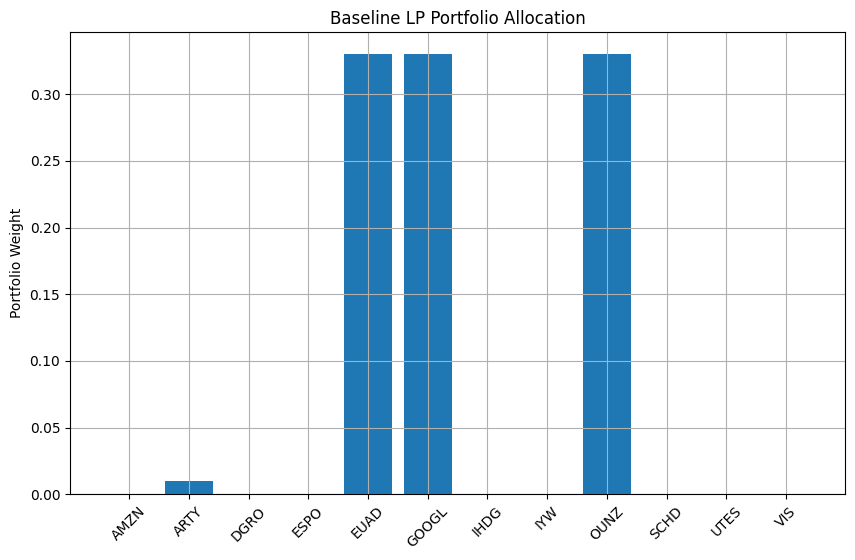

In [3]:

returns, mean_returns, risk = compute_returns(prices)

weights, portfolio_return = baseline_lp(mean_returns)

weights_df = pd.DataFrame({
    "Asset": prices.columns,
    "Weight": weights
})

weights_df["Weight"] = weights_df["Weight"].round(4)

print(weights_df)

print(f"Expected Portfolio Return: {portfolio_return:.4f}")

plot_weights(
    weights,
    prices.columns,
    "Baseline LP Portfolio Allocation"
)

## Risk Constrained LP

    Asset  Weight
0    AMZN  0.0000
1    ARTY  0.0000
2    DGRO  0.3300
3    ESPO  0.0000
4    EUAD  0.2007
5   GOOGL  0.0000
6    IHDG  0.0000
7     IYW  0.0000
8    OUNZ  0.3300
9    SCHD  0.1393
10   UTES  0.0000
11    VIS  0.0000


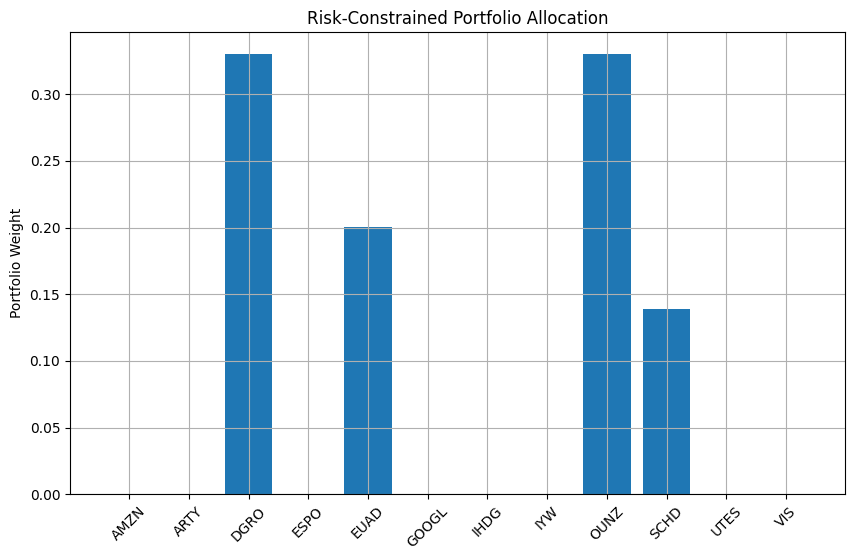

In [4]:

risk_weights, risk_return, risk_value = risk_constrained_lp(
    mean_returns,
    risk
)

risk_df = pd.DataFrame({
    "Asset":  prices.columns,
    "Weight": risk_weights
})

risk_df["Weight"] = risk_df["Weight"].round(4)

print(risk_df)

plot_weights(
    risk_weights,
    prices.columns,
    "Risk-Constrained Portfolio Allocation"
)

## MILP

In [5]:

current_weights = pd.Series(
    np.ones(len(prices.columns)) / len(prices.columns),
    index=prices.columns
)

(
    milp_weights,
    buys,
    sells,
    traded,
    milp_return
) = milp_rebalancing(
    mean_returns,
    current_weights
)

milp_df = pd.DataFrame({
    "Asset": prices.columns,
    "NewWeight": milp_weights,
    "Buy": buys,
    "Sell": sells,
    "Traded": traded
})

milp_df.round(4)

,Asset,NewWeight,Buy,Sell,Traded
0,AMZN,0.00,0.0000,0.0833,1.0
1,ARTY,0.01,0.0000,0.0733,1.0
2,DGRO,0.00,0.0000,0.0833,1.0
3,ESPO,0.00,0.0000,0.0833,1.0
4,EUAD,0.33,0.2467,0.0000,1.0
5,GOOGL,0.33,0.2467,0.0000,1.0
6,IHDG,0.00,0.0000,0.0833,1.0
7,IYW,0.00,0.0000,0.0833,1.0
8,OUNZ,0.33,0.2467,0.0000,1.0
9,SCHD,0.00,0.0000,0.0833,1.0


## QP

Expected Return: 0.4848
Portfolio Risk: 0.1780
Sharpe Ratio: 2.5550


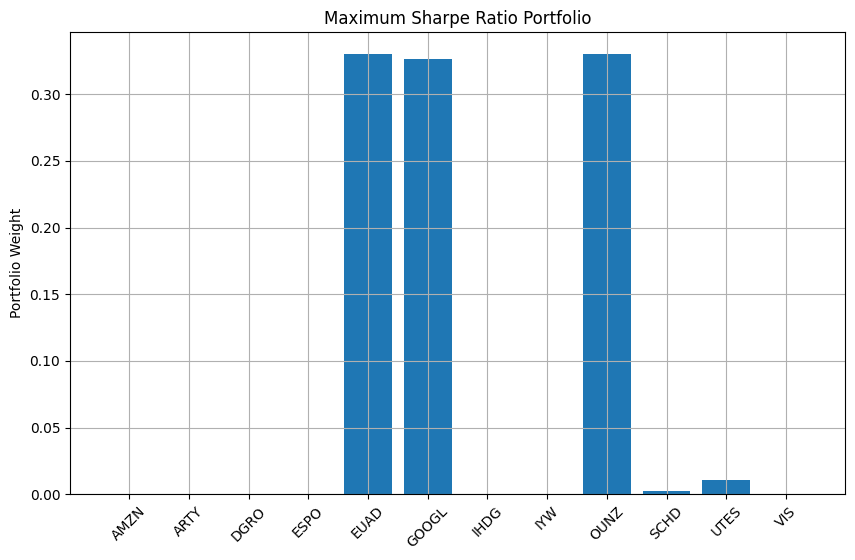

In [6]:
cov_matrix = compute_covariance_matrix(
    returns
)

(
    sharpe_weights,
    sharpe_return,
    sharpe_risk,
    sharpe_ratio
) = sharpe_optimization(
    mean_returns,
    cov_matrix
)

sharpe_df = pd.DataFrame({
    "Asset": prices.columns,
    "Weight": sharpe_weights
})

sharpe_df["Weight"] = sharpe_df["Weight"].round(4)

sharpe_df

print(f"Expected Return: {sharpe_return:.4f}")
print(f"Portfolio Risk: {sharpe_risk:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

plot_weights(
    sharpe_weights,
    prices.columns,
    "Maximum Sharpe Ratio Portfolio"
)